In [2]:
import sys

if "google.colab" in sys.modules:
    # Mount Google Drive
    from google.colab import drive
    drive.mount('/content/drive')
    original_data = '/content/drive/My Drive/original_dataset'
    final_data = '/content/drive/My Drive/Final_Dataset'

    # Install required packages
    !pip install pymatgen torch_geometric mp_api

else:
    original_data = "original_dataset"
    final_data = "Final_Dataset"   

In [3]:
import pandas as pd
from pymatgen.core import Structure
import to_graph
import combine
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch_geometric.data import Data


/home/mac07/anaconda3/envs/env00/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [45]:
comb_df = pd.read_csv(f"{final_data}/combined/combined_data.csv")
comb_df.head()

,_id,dataset_material,vacancy_sites,substitution_sites,defect_sites,band_gap_value,strata
0,BN_B62C2N63_816498e1-eef8-400f-93d4-17a0a435389a,high_BN,1.0,2.0,3.0,0.47870,0
1,BN_B62C1N63_631c0dc0-4762-4e3c-93ba-d4876a1b7997,high_BN,2.0,1.0,3.0,0.59710,0
2,BN_B63C2N62_5ea09385-eb62-43dc-9334-9142794a8de0,high_BN,1.0,2.0,3.0,0.84450,0
3,BN_B63C1N62_e4656f55-37a8-4fcf-bec1-fd7cc833f86b,high_BN,2.0,1.0,3.0,0.87055,0
4,BN_B62C2N63_91fe1ce6-6a19-4a26-8caa-82caf4ca6ac2,high_BN,1.0,2.0,3.0,1.84640,0


In [46]:
# Get 1000 data points
from sklearn.preprocessing import StandardScaler
comb_df = comb_df.sample(n=1500, random_state=42, ignore_index=True)

scaler = StandardScaler()
comb_df['band_gap_value'] = scaler.fit_transform(comb_df[['band_gap_value']])

In [47]:
# Split the data
from sklearn.model_selection import train_test_split
from torch_geometric.loader import DataLoader

train_set, test_set = train_test_split(comb_df, test_size=0.35, stratify=comb_df['dataset_material'], random_state=42)
test_set, val_set = train_test_split(test_set, test_size=0.5, random_state=42)

# Create graph representation of the structures
def graphy(row):
    defective_structure = Structure.from_file(f"{original_data}/{row["dataset_material"]}/cifs/{row["_id"]}.cif")
    reference_structure = Structure.from_file(f"{final_data}/ref_cifs/{row["dataset_material"]}.cif")

    defects_only_structure = to_graph.get_defects_structure(defective_structure, reference_structure)

    # nodes, edges, edge_features, ids, ratios = to_graph.get_c_graph(defects_only_structure)
    nodes, edges, edge_features, globals = to_graph.get_c_graph(defects_only_structure)

    # Scale the target variable
    target = row["band_gap_value"]

    the_data = Data(
        x=torch.tensor(nodes, dtype=torch.float),
        edge_index=torch.tensor(edges, dtype=torch.long),
        edge_attr=torch.tensor(edge_features, dtype=torch.float),
        u=torch.tensor(globals, dtype=torch.float).unsqueeze(0),
        y=torch.tensor(target, dtype=torch.float).unsqueeze(0)
    )
    return the_data

In [48]:

# Turn each dataset into graph data
train_graphs = train_set.apply(lambda row: graphy(row), axis = 1).tolist()
val_graphs = val_set.apply(lambda row: graphy(row), axis = 1).tolist()
test_graphs = test_set.apply(lambda row: graphy(row), axis = 1).tolist()

# Create data loaders
train_loader = DataLoader(train_graphs, batch_size=32, shuffle=True)
val_loader = DataLoader(val_graphs, batch_size=32, shuffle=False)
test_loader = DataLoader(test_graphs, batch_size=32, shuffle=False)

/home/mac07/anaconda3/envs/env00/lib/python3.14/site-packages/pymatgen/core/structure.py:3112: UserWarning: Issues encountered while parsing CIF: 48 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/home/mac07/anaconda3/envs/env00/lib/python3.14/site-packages/pymatgen/core/structure.py:3112: UserWarning: Issues encountered while parsing CIF: 44 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/home/mac07/anaconda3/envs/env00/lib/python3.14/site-packages/pymatgen/core/structure.py:3112: UserWarning: Issues encountered while parsing CIF: 47 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/home/mac07/anaconda3/envs/env00/lib/python3.14/site-packages/pymatgen/core/structure.py:3112: UserWarning: Issues enc

In [8]:
# Inspect the first batch from the train loader
for batch in train_loader:
    print("Batch info:")
    print(f"  Number of graphs in batch: {batch.num_graphs}")
    print(f"  Total nodes: {batch.x.shape[0]}")
    print(f"  Node features shape: {batch.x.shape}")  # Shape: [total_nodes, feature_dim]
    print(f"  Edge index shape: {batch.edge_index.shape}")  # Shape: [2, total_edges]
    print(f"  Edge attributes shape: {batch.edge_attr.shape}")  # Shape: [total_edges, edge_feature_dim]
    print(f"  U shape: {batch.u.shape}")  # Shape: [batch_size, 119]
    print(f"  Target shape: {batch.y.shape}")  # Shape: [batch_size, 1] (scaled band gap)
    
    break

Batch info:
  Number of graphs in batch: 32
  Total nodes: 167
  Node features shape: torch.Size([167, 8])
  Edge index shape: torch.Size([2, 1417])
  Edge attributes shape: torch.Size([1417, 3])
  U shape: torch.Size([32, 119])
  Target shape: torch.Size([32])


# The Model

In [9]:
# import dependancies
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import global_mean_pool, NNConv, Sequential, Linear, CGConv


## CGConv-only model version
This version uses only `CGConv` layers for graph message passing and keeps the global feature embedding from `data.u`.

In [ ]:
class GNNModelCG(nn.Module):
    def __init__(self, node_dim=8, hidden_dim=64, embed_dim=64, u_dim=119):
        super().__init__()
        self.conv1 = CGConv(node_dim, dim=3, aggr='mean')
        self.conv2 = CGConv(hidden_dim, dim=3, aggr='mean')

        self.global_embed = nn.Linear(u_dim, embed_dim)

        self.fc = nn.Sequential(
            nn.Linear(hidden_dim + embed_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, data):
        x = F.relu(self.conv1(data.x, data.edge_index, data.edge_attr))
        x = F.relu(self.conv2(x, data.edge_index, data.edge_attr))

        x = global_mean_pool(x, data.batch)
        u = self.global_embed(data.u)

        x = torch.cat([x, u], dim=1)
        return self.fc(x)

# Use the CGConv-only model if you want a simpler graph architecture.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
GNN_model_cg = GNNModelCG().to(device)

# optimizer
optimizer = torch.optim.Adam(GNN_model_cg.parameters(), lr=0.001)

In [58]:
class GNNModel(nn.Module):
    def __init__(self, node_dim=8, edge_dim=3, hidden_dim=128, embed_dim=10, global_dim=119):
        super().__init__()

        # Edge network for NNConv: maps each edge_attr to a weight matrix
        self.edge_mlp = nn.Sequential(
            nn.Linear(edge_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, node_dim * hidden_dim),
        )

        # First message-passing layer
        self.conv1 = NNConv(node_dim, hidden_dim, self.edge_mlp, aggr='mean')

        # Second message-passing layer using CGConv
        self.conv2 = CGConv(hidden_dim, dim=3, aggr='mean')
        self.conv3 = CGConv(hidden_dim, dim=3, aggr='mean')

        # Embed the graph-level global features
        self.global_embed = nn.Linear(global_dim, embed_dim)

        # Final MLP head
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim + embed_dim, 128),
            nn.Dropout(0.2),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.Dropout(0.2),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.Dropout(0.2),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, data):
        x, edge_index, edge_attr, batch, u = (
            data.x,
            data.edge_index,
            data.edge_attr,
            data.batch,
            data.u,
        )

        x = F.relu(self.conv1(x, edge_index, edge_attr))
        x = F.relu(self.conv2(x, edge_index, edge_attr))
        x = F.relu(self.conv3(x, edge_index, edge_attr))

        x = global_mean_pool(x, batch)
        u = self.global_embed(u)

        x = torch.cat([x, u], dim=1)
        return self.fc(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
GNN_Model = GNNModel().to(device)

# optimizer
optimizer = torch.optim.Adam(GNN_Model.parameters(), lr=0.0001)

In [59]:
class LogCoshLoss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, input, target):
        ey_t = input-target
        return torch.mean(torch.log(torch.cosh(ey_t + 1e-12)))
    

class RelativeMSELoss(nn.Module):
    def __inti__(self):
        super().__init__()

    def forward(self, y_pred, y_true):
        return torch.mean(((y_pred-y_true)/ (y_true + 1e-8)) ** 2)
    

class SMAPELoss(nn.Module):
    def __inti__(self):
        super().__init__()

    def forward(self, y_pred, y_true):
        numerator = torch.abs(y_pred - y_true)
        denominator = (torch.abs(y_true) + torch.abs(y_pred))/2.0 + 1e-8
        return torch.mean(numerator/denominator)
    
# Loss function
loss_fn = nn.MSELoss()
# loss_fn = LogCoshLoss()
# loss_fn = RelativeMSELoss()
# loss_fn = SMAPELoss()



In [60]:
def train(model):
    model.train()
    total_loss = 0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()

        out = model(data)
        loss = loss_fn(out, data.y)

        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    return total_loss / len(train_loader.dataset)

def evaluate(model, loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for data in loader:
            data = data.to(device)

            out = model(data)
            loss = loss_fn(out, data.y)

            total_loss += loss.item() * data.num_graphs
    return total_loss / len(loader.dataset)

def predict(model, loader, actuals=False):
    model.eval()
    if actuals:
        predictions = []
        actual = []
        with torch.no_grad():
            for data in loader:
                data = data.to(device)

                out = model(data)
                predictions.append(out.cpu().numpy())
                actual.append(data.y.cpu().numpy())

        predictions = np.concatenate(predictions, axis=0).flatten()
        actual = np.concatenate(actual, axis=0).flatten()
        return predictions, actual
    else:
        predictions = []
        with torch.no_grad():
            for data in loader:
                data = data.to(device)

                out = model(data)
                predictions.append(out.cpu().numpy())

        predictions = np.concatenate(predictions, axis=0).flatten()
        return predictions

In [61]:
# Train model
the_model = GNN_Model
# the_model = GNN_model_cg
train_losses = []
val_losses = []
for epoch in range(1, 41):
    train_loss = train(the_model)
    val_loss = evaluate(the_model,val_loader)
    print(f'Epoch {epoch:03d}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')
    train_losses.append(train_loss)
    val_losses.append(val_loss)

# Test model
test_loss = evaluate(the_model, test_loader)
print(f'Test Loss: {test_loss:.4f}')

/home/mac07/anaconda3/envs/env00/lib/python3.14/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([32])) that is different to the input size (torch.Size([32, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/home/mac07/anaconda3/envs/env00/lib/python3.14/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([15])) that is different to the input size (torch.Size([15, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/home/mac07/anaconda3/envs/env00/lib/python3.14/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([7])) that is different to the input size (torch.Size([7, 1])). This will likely lead to incorrect results due to broadcasting. P

Epoch 001, Train Loss: 1.9611, Val Loss: 1.0213
Epoch 002, Train Loss: 1.1653, Val Loss: 0.9973
Epoch 003, Train Loss: 1.0866, Val Loss: 0.9847
Epoch 004, Train Loss: 1.0561, Val Loss: 0.9809
Epoch 005, Train Loss: 1.0470, Val Loss: 0.9795
Epoch 006, Train Loss: 1.0362, Val Loss: 0.9787
Epoch 007, Train Loss: 1.0309, Val Loss: 0.9785
Epoch 008, Train Loss: 1.0288, Val Loss: 0.9783
Epoch 009, Train Loss: 1.0222, Val Loss: 0.9780
Epoch 010, Train Loss: 1.0237, Val Loss: 0.9794
Epoch 011, Train Loss: 1.0224, Val Loss: 0.9764
Epoch 012, Train Loss: 1.0215, Val Loss: 0.9760
Epoch 013, Train Loss: 1.0184, Val Loss: 0.9754
Epoch 014, Train Loss: 1.0163, Val Loss: 0.9762
Epoch 015, Train Loss: 1.0176, Val Loss: 0.9748
Epoch 016, Train Loss: 1.0180, Val Loss: 0.9752
Epoch 017, Train Loss: 1.0149, Val Loss: 0.9744
Epoch 018, Train Loss: 1.0160, Val Loss: 0.9733
Epoch 019, Train Loss: 1.0138, Val Loss: 0.9733
Epoch 020, Train Loss: 1.0136, Val Loss: 0.9727
Epoch 021, Train Loss: 1.0122, Val Loss:

/home/mac07/anaconda3/envs/env00/lib/python3.14/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([6])) that is different to the input size (torch.Size([6, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


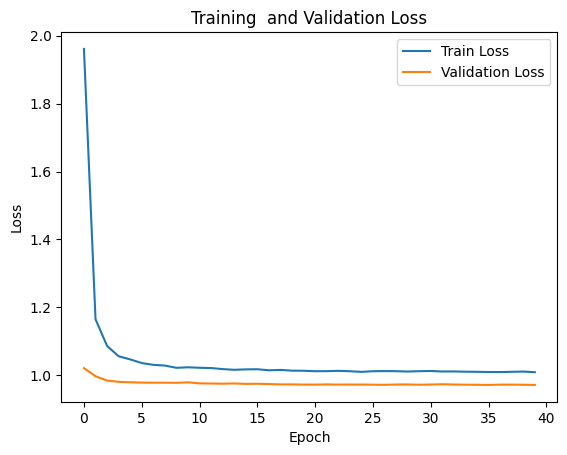

In [62]:
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training  and Validation Loss')
plt.legend()
plt.show()

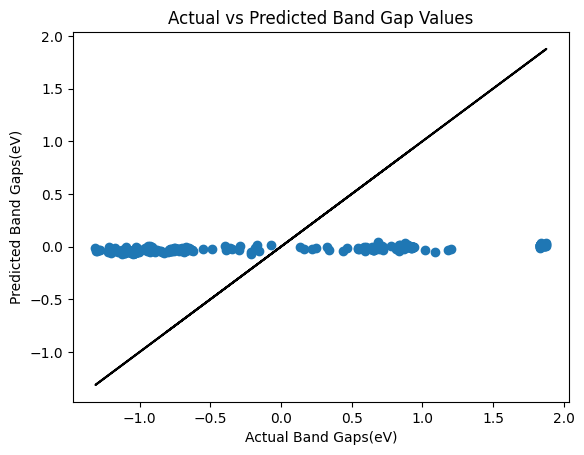

In [63]:
# model values
predicted_values, actual_values = predict(the_model, test_loader, actuals=True)

# Produce a graph
plt.scatter(actual_values, predicted_values )
plt.plot(actual_values, actual_values, c="black")
plt.xlabel('Actual Band Gaps(eV)')
plt.ylabel('Predicted Band Gaps(eV)')
plt.title('Actual vs Predicted Band Gap Values')
plt.show()

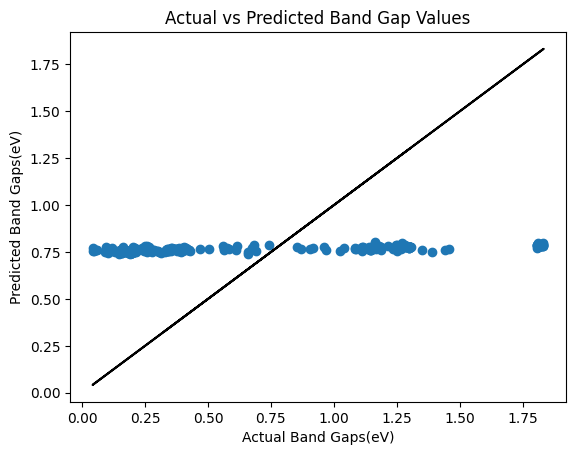

In [64]:
# Turn from sclaed to normal
the_mean = scaler.mean_
the_scale = scaler.scale_

predicted_values = predicted_values * the_scale + the_mean
actual_values = actual_values * the_scale + the_mean

# Produce a graph
plt.scatter(actual_values, predicted_values )
plt.plot(actual_values, actual_values, c="black")
plt.xlabel('Actual Band Gaps(eV)')
plt.ylabel('Predicted Band Gaps(eV)')
plt.title('Actual vs Predicted Band Gap Values')
plt.show()

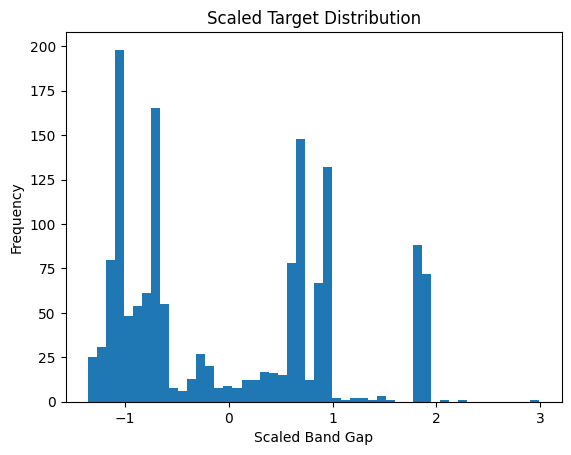

Scaled Min: -1.353
Scaled Max: 2.990
Scaled Mean: -0.000
Scaled Std: 1.000


In [65]:
# Diagnostic: Check target distribution after scaling
plt.hist(comb_df['band_gap_value'], bins=50)
plt.xlabel('Scaled Band Gap')
plt.ylabel('Frequency')
plt.title('Scaled Target Distribution')
plt.show()

print(f"Scaled Min: {comb_df['band_gap_value'].min():.3f}")
print(f"Scaled Max: {comb_df['band_gap_value'].max():.3f}")
print(f"Scaled Mean: {comb_df['band_gap_value'].mean():.3f}")
print(f"Scaled Std: {comb_df['band_gap_value'].std():.3f}")


In [66]:

# Diagnostic: Inspect node and edge features for variance
# Get a sample graph
sample_data = train_graphs[0]

print("Node features (first 5 nodes):")
print(sample_data.x[:5])
print(f"Node feature std: {sample_data.x.std(dim=0)}")

print("\nEdge attributes (first 5 edges):")
print(sample_data.edge_attr[:5])
print(f"Edge feature std: {sample_data.edge_attr.std(dim=0)}")

print(f"\nGlobal features (u): {sample_data.u.shape}")
print(f"Global feature std: {sample_data.u.std(dim=1)}")


Node features (first 5 nodes):
tensor([[  0.0000,   6.0000,  74.0000,   0.0000, -74.0000,   1.0000,   0.0000,
          13.0106],
        [  1.0000,   3.0000,  34.0000,   0.0000, -34.0000,   1.0000,   0.0000,
           3.4890],
        [  2.0000,   0.0000,  34.0000,  16.0000, -18.0000,   0.0000,   1.0000,
          -0.6380]])
Node feature std: tensor([ 1.0000,  3.0000, 23.0940,  9.2376, 28.8444,  0.5774,  0.5774,  6.9997])

Edge attributes (first 5 edges):
tensor([[ 0.0000,  1.0000,  0.0000],
        [ 8.5447,  0.0000,  9.5216],
        [ 4.1865,  0.0000, 13.6486],
        [ 8.5447,  0.0000,  9.5216],
        [ 0.0000,  1.0000,  0.0000]])
Edge feature std: tensor([3.5860, 0.5000, 5.6655])

Global features (u): torch.Size([1, 119])
Global feature std: tensor([0.0681])


In [67]:

# Diagnostic: Check if model outputs vary
# Run a forward pass on a few batches and inspect outputs
the_model.eval()
with torch.no_grad():
    for i, data in enumerate(train_loader):
        if i >= 3: break  # Check first 3 batches
        data = data.to(device)
        out = the_model(data)
        print(f"Batch {i+1} predictions: min={out.min().item():.3f}, max={out.max().item():.3f}, mean={out.mean().item():.3f}, std={out.std().item():.3f}")
        print(f"Targets: min={data.y.min().item():.3f}, max={data.y.max().item():.3f}, mean={data.y.mean().item():.3f}, std={data.y.std().item():.3f}")


Batch 1 predictions: min=-0.058, max=0.012, mean=-0.019, std=0.018
Targets: min=-1.174, max=1.837, mean=-0.071, std=0.932
Batch 2 predictions: min=-0.062, max=0.021, mean=-0.019, std=0.022
Targets: min=-1.170, max=1.935, mean=0.013, std=1.108
Batch 3 predictions: min=-0.054, max=0.025, mean=-0.020, std=0.020
Targets: min=-1.256, max=1.865, mean=0.072, std=1.042
